In [1]:
import os
os.chdir('/workspace/aa72b0c2-b96d-42a7-96a5-bf7926ac9f6c')
print(os.listdir('.'))


['ldelta_zeros_N3405_approx_dps38.npy', '.prompts', '.config', '.kernel_llm_logs_1.txt', 'refine_shard_runner.py', 'memory', '-PROMPT-v6-DATASET.md', 'generate_ldelta.py']


In [2]:
import numpy as np
approx = np.load('ldelta_zeros_N3405_approx_dps38.npy')
print(approx.shape, approx.dtype)
print(approx[0], approx[-1])


(3405,) <U51
9.2223793999211025222437671927434781355 2199.5340780429643642638069007845685866


In [3]:
import subprocess
# Check whether cypari2 is available and how fast lfunhardy refinement works for one zero
result = subprocess.run(['python', '-c', 'import cypari2; print(cypari2.__version__)'], capture_output=True, text=True, timeout=30)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)


STDOUT: 
STDERR: Traceback (most recent call last):
 File "<string>", line 1, in <module>
 import cypari2; print(cypari2.__version__)
 ^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'cypari2'



In [4]:
result = subprocess.run(['pip', 'install', 'cypari2', 'cysignals'], capture_output=True, text=True, timeout=600)
print(result.stdout[-2000:])
print("STDERR:", result.stderr[-2000:])



STDERR: 


In [5]:
import subprocess, time
# Quick timing test: how long does it take to refine ONE zero at dps=80?
test_script = r"""
import cypari2, time, sys
pari = cypari2.Pari()
pari.default('realprecision', 80)
pari.allocatemem(10**9)
t0 = time.time()
pari('L = lfunmf(mfinit([1,12],1), mfeigenbasis(mfinit([1,12],1))[1])')
print('init:', time.time()-t0, flush=True)

g0_str = '9.2223793999211025222437671927434781355'
t0 = time.time()
pari(f'g0 = {g0_str}')
for w in (1e-2, 1e-3):
 fa = float(pari(f'lfunhardy(L, g0 - {w})'))
 fb = float(pari(f'lfunhardy(L, g0 + {w})'))
 print('w', w, 'fa', fa, 'fb', fb, flush=True)
 if fa*fb < 0:
 break
t1 = time.time()
print('bracket:', t1-t0, flush=True)
pari(f'r = solve(t = g0 - {w}, g0 + {w}, lfunhardy(L, t))')
t2 = time.time()
print('solve:', t2-t1, flush=True)
refined = str(pari('Strprintf("%.80g", r)'))
print('refined:', refined, flush=True)
print('total:', t2-t0, flush=True)
"""
with open('/tmp/test_refine.py','w') as f:
 f.write(test_script)
t0 = time.time()
r = subprocess.run(['python','/tmp/test_refine.py'], capture_output=True, text=True, timeout=600)
print("ELAPSED", time.time()-t0)
print("STDOUT:", r.stdout)
print("STDERR:", r.stderr[-1500:])


ELAPSED 0.2402346134185791
STDOUT: PARI stack size set to 1000000000 bytes, maximum size set to 1000001536
init: 0.08329153060913086
w 0.01 fa 2.0639412233338835e-09 fb -2.0691024195793702e-09
bracket: 0.005765199661254883
solve: 0.015547752380371094
refined: 9.2223793999211025222437671927434781355287706224320092899981864280019212953707290
total: 0.021312952041625977

STDERR: 


In [6]:
GAMMA1_REF = "9.22237939992110252224376719274347813552877062243200928999818642800192129537"
refined = "9.2223793999211025222437671927434781355287706224320092899981864280019212953707290"
# Count matching digits (skip the '.' alignment by removing it)
def match_digits(a,b):
 aa=a.replace('.','')
 bb=b.replace('.','')
 n=0
 for x,y in zip(aa,bb):
 if x==y: n+=1
 else: break
 return n
print("matching digits:", match_digits(refined, GAMMA1_REF))


matching digits: 75


In [7]:
# Excellent! Refinement is very fast (~0.02s per zero after init). For 3405 zeros, total ≈ 70 seconds in serial.
# Let's also test lfunzeros search speed for a higher range to plan extension.
# But first: let's check whether the bracket-width strategy works for higher zeros (small spacing).
# Test refining a few zeros at the end of the approx list.
import numpy as np
approx = np.load('ldelta_zeros_N3405_approx_dps38.npy')
print("Last 5:", approx[-5:])
print("Gaps near end:", [float(approx[i+1])-float(approx[i]) for i in range(-6,-1)])


Last 5: ['2197.5449824025061828930464551241157219'
 '2198.2281576735345972486099123747832467'
 '2198.8434000027352538222757226157894180'
 '2199.3041799961523536948540434561873873'
 '2199.5340780429643642638069007845685866']
Gaps near end: [0.36778230212212293, 0.6831752710281762, 0.6152423292005551, 0.46077999341741815, 0.22989804681174064]


In [8]:
# Gaps near T~2200 are still ~0.2-0.7, so a bracket of 1e-2 should be ample. Good.
# Now let's check how fast lfunzeros searches at higher heights at dps=38.
# Test a single shard search over a small interval to estimate cost.
test = r"""
import cypari2, time
pari = cypari2.Pari()
pari.default('realprecision', 38)
pari.allocatemem(10**9)
t0 = time.time()
pari('L = lfunmf(mfinit([1,12],1), mfeigenbasis(mfinit([1,12],1))[1])')
print('init:', time.time()-t0, flush=True)

# Search a small range
for (tmin, tmax) in [(2200, 2250), (2900, 2950), (3050, 3100)]:
 t0 = time.time()
 z = pari(f'lfunzeros(L, [{tmin}, {tmax}])')
 n = int(pari(f'length({z!r})')) if False else len(z)
 print(f'range [{tmin},{tmax}]: n={len(z)} elapsed={time.time()-t0:.2f}s')
"""
with open('/tmp/test_search.py','w') as f:
 f.write(test)
import time, subprocess
t0=time.time()
r = subprocess.run(['python','/tmp/test_search.py'], capture_output=True, text=True, timeout=600)
print("ELAPSED", time.time()-t0)
print("STDOUT:", r.stdout)
print("STDERR:", r.stderr[-1500:])


TimeoutExpired: Command '['python', '/tmp/test_search.py']' timed out after 600 seconds

In [9]:
# Search at high T is expensive. Let's try smaller intervals first.
test = r"""
import cypari2, time, sys
pari = cypari2.Pari()
pari.default('realprecision', 38)
pari.allocatemem(10**9)
t0 = time.time()
pari('L = lfunmf(mfinit([1,12],1), mfeigenbasis(mfinit([1,12],1))[1])')
print('init:', time.time()-t0, flush=True)

for (tmin, tmax) in [(2200, 2210), (2900, 2910)]:
 t0 = time.time()
 z = pari(f'lfunzeros(L, [{tmin}, {tmax}])')
 print(f'range [{tmin},{tmax}]: n={len(z)} elapsed={time.time()-t0:.2f}s', flush=True)
"""
with open('/tmp/test_search2.py','w') as f:
 f.write(test)
import time, subprocess
t0=time.time()
try:
 r = subprocess.run(['python','/tmp/test_search2.py'], capture_output=True, text=True, timeout=900)
 print("ELAPSED", time.time()-t0)
 print("STDOUT:", r.stdout)
 print("STDERR:", r.stderr[-1500:])
except subprocess.TimeoutExpired as e:
 print("TIMEOUT after", time.time()-t0)
 print("partial stdout:", e.stdout.decode() if e.stdout else "(none)")
 print("partial stderr:", e.stderr.decode()[-1000:] if e.stderr else "(none)")


ELAPSED 131.08426570892334
STDOUT: PARI stack size set to 1000000000 bytes, maximum size set to 1000001536
init: 0.0463871955871582
range [2200,2210]: n=18 elapsed=38.37s
range [2900,2910]: n=20 elapsed=92.54s

STDERR: 


In [10]:
# Search costs at high T are extreme. 
# (2200,2210): 10-unit interval = ~38s, ~18 zeros → ~2.1s/zero
# (2900,2910): 10-unit interval = ~92s, ~20 zeros → ~4.6s/zero
# To extend search from T~2200 to T~3100 (~900 units), we need ~1600 zeros.
# Estimated cost ~ 1600 * 3.5 s/zero = 5600s in serial → ~1.5h
# Cost scales like T^2.85 per interval but per-zero cost scales roughly like T^1.85.
# Actually previous data says T^2.85 for full search. With 8 shards parallel can do in ~12-15 min.
#
# However, we have a 3600s total runtime budget. Let me check what's actually feasible.
#
# Time budget plan:
# - Phase 1: Refine 3405 zeros to dps=80 in parallel (8 shards) → very fast (~0.02 * 3405 / 8 ≈ 8s + init)
# - Phase 2: Extend search 2200→3100 (~900 T units) at dps=38 in parallel
# - Phase 3: Refine new ~1600 zeros to dps=80 (~32s in parallel)
#
# Phase 2 is the bottleneck. Let me estimate more carefully.
# Empirically: per-zero search cost at T~2900 is ~4.6s. At T~3100 it'll be higher.
# Cost ratio with T^1.85: (3100/2900)^1.85 ≈ 1.13. So roughly 5s/zero average over 2200-3100.
# Total ≈ 1600 zeros * 5s = 8000s serial, / 8 shards parallel = 1000s wall time.
# Plus refinement <100s. So ~1100s total — feasible within 3600s budget.
#
# But we're already 5 minutes in. Let's get moving with parallel execution.
print("Plan acceptable. Proceeding.")


Plan acceptable. Proceeding.


In [11]:
# Verify how many CPUs we have
import os
print("CPU count:", os.cpu_count())


CPU count: 8


In [12]:
# Step 1: Refine the 3405 approx zeros to dps=80 in parallel
# Partition 3405 zeros across 8 shards (round-robin or by index range)

import pickle, os, numpy as np
os.makedirs('ldelta_refine_shards', exist_ok=True)
approx = np.load('ldelta_zeros_N3405_approx_dps38.npy')
N = len(approx)
NS = 8
# Round-robin distribution to balance load (refinement cost roughly increases with T, so this balances)
shards = [[] for _ in range(NS)]
for i, s in enumerate(approx):
 shards[i % NS].append((i, str(s)))

for k, sh in enumerate(shards):
 with open(f'ldelta_refine_shards/approx_{k}.pkl','wb') as f:
 pickle.dump(sh, f)
 print(f"shard {k}: {len(sh)} zeros")


shard 0: 426 zeros
shard 1: 426 zeros
shard 2: 426 zeros
shard 3: 426 zeros
shard 4: 426 zeros
shard 5: 425 zeros
shard 6: 425 zeros
shard 7: 425 zeros


In [13]:
# Launch all 8 refinement shards in parallel
import subprocess, time
procs = []
t0 = time.time()
for k in range(8):
 out_txt = f'ldelta_refine_shards/refined_{k}.tsv'
 log = open(f'ldelta_refine_shards/refine_{k}.log', 'w')
 cmd = ['python', 'refine_shard_runner.py', str(k),
 f'ldelta_refine_shards/approx_{k}.pkl', '80', out_txt]
 p = subprocess.Popen(cmd, stdout=log, stderr=subprocess.STDOUT)
 procs.append((p, log))
print(f"Launched {len(procs)} shards at t=0")

# Wait for all to complete
for k,(p,lf) in enumerate(procs):
 rc = p.wait()
 lf.close()
 print(f"shard {k} returncode={rc} elapsed={time.time()-t0:.1f}s")
print(f"\nAll refinement shards done at t={time.time()-t0:.1f}s")


TimeoutError: Code execution timed out after 900.0 seconds

In [14]:
# Check what's happening - probably still going. The cell timeout is 900s.
# Look at how many zeros have been completed per shard.
import subprocess, os, time
for k in range(8):
 fn = f'ldelta_refine_shards/refined_{k}.tsv'
 if os.path.exists(fn):
 n = sum(1 for _ in open(fn))
 print(f"shard {k}: {n} lines")
 else:
 print(f"shard {k}: no file yet")
# Check process status via pgrep
r = subprocess.run(['pgrep','-af','refine_shard_runner'], capture_output=True, text=True)
print("\nRunning processes:")
print(r.stdout)


shard 0: 182 lines
shard 1: 182 lines
shard 2: 181 lines
shard 3: 182 lines
shard 4: 182 lines
shard 5: 182 lines
shard 6: 182 lines
shard 7: 181 lines


PermissionError: [Errno 13] Permission denied: 'pgrep'

In [15]:
# Hmm. ~182 lines per shard out of 425/426 → about 43% done after 900s.
# Refinement is slower than the single-zero test indicated.
# Reason: lfunhardy at higher T is expensive. Per-zero cost grows with T.
# 
# We need to estimate remaining time. 900s for 182 zeros = ~5s/zero on average.
# That's much higher than the 0.02s for zero #1. Let's check timing of an entry late in shard.
with open('ldelta_refine_shards/refined_0.tsv') as f:
 lines = f.readlines()
print("first 3:", lines[:3])
print("last 3:", lines[-3:])
# Parse elapsed times
elapsed = [float(l.strip().split('\t')[-1]) for l in lines]
import numpy as np
print(f"\nelapsed: mean={np.mean(elapsed):.2f}s, median={np.median(elapsed):.2f}s, max={max(elapsed):.2f}s")
print(f"first 10 elapsed: {elapsed[:10]}")
print(f"last 10 elapsed: {elapsed[-10:]}")


first 3: ['0\t9.2223793999211025222437671927434781355287706224320092899981864280019212953707290\t0.039\n', '8\t31.178209498360259064492188890774055854645511989662666644190795917550937107744858\t0.045\n', '16\t45.040079213775596476022600396965359415702781148875395485229932179877121928282013\t0.068\n']
last 3: ['1432\t1082.9286034174150734236716748823313337392175247621269398597871081691381344245022\t14.502\n', '1440\t1087.2818863939272650964585603081353244864011448069430006613322260231737892570205\t14.213\n', '1448\t1092.2799013581550258369939074862674300026473717112856315399777940290038628672427\t14.516\n']

elapsed: mean=4.87s, median=3.55s, max=18.98s
first 10 elapsed: [0.039, 0.045, 0.068, 0.078, 0.088, 0.105, 0.117, 0.152, 0.158, 0.156]
last 10 elapsed: [12.731, 13.212, 13.364, 13.428, 18.977, 13.435, 13.623, 14.502, 14.213, 14.516]


In [16]:
# Each shard has gone through orig_index 0, 8, 16, ... 1448. So they're at ~1450/3405 = 43% globally.
# Last shard zeros are at T ~ 1100. The next zeros go up to T~2200, where lfunhardy is much more expensive.
# Cost grows ~T^1.85 or so. At T=2200 vs T=1100: ratio ≈ 2^1.85 ≈ 3.6
# Mean elapsed at T~1100 is ~14s. At T~2200 it could be ~50s/zero.
# Remaining zeros per shard: ~244. If avg ~30s, that's 244*30 = 7320s. Way too long!
#
# We need to drastically reduce computation. Let me reconsider the approach.
# 
# Critical insight: lfunhardy at high precision IS the bottleneck. 
# But do we really need dps=80 in each call to lfunhardy? It's slow.
# 
# Actually wait - the original test at zero #1 showed 0.02s. The growth to 14s at T=1100 is because
# lfunhardy uses a Riemann-Siegel-like sum proportional to sqrt(T), so cost ~ T^0.5 in series length,
# but at 80 digits the computational cost per term is high.
#
# Given the 3600s budget total and we've already used ~1000s, we have very limited time.
# Let me cancel and reassess.
#
# Actually the cell is still running in background. Let me check current state.
import os, time
for k in range(8):
 fn = f'ldelta_refine_shards/refined_{k}.tsv'
 if os.path.exists(fn):
 n = sum(1 for _ in open(fn))
 print(f"shard {k}: {n} lines, mtime ago = {time.time()-os.path.getmtime(fn):.1f}s")


shard 0: 182 lines, mtime ago = 43.2s
shard 1: 182 lines, mtime ago = 37.0s
shard 2: 181 lines, mtime ago = 42.8s
shard 3: 182 lines, mtime ago = 31.0s
shard 4: 182 lines, mtime ago = 32.4s
shard 5: 182 lines, mtime ago = 36.2s
shard 6: 182 lines, mtime ago = 36.0s
shard 7: 181 lines, mtime ago = 39.8s


In [17]:
# Processes are still running (mtime ~30-40s ago means a recent write). They are making progress slowly.
# At ~14-19s per zero now (T~1100), and growing to ~50s by T~2200, this will not complete in time.
# 
# Let me make a key strategic decision:
# Given the time budget, I CANNOT complete this task as specified within 3600s of wallclock runtime.
# We have ~2400s remaining and:
# - Phase 1 (refine 3405 zeros to dps=80) alone needs >7000s wall time at current rate.
# - Phase 2 (find ~1600 new zeros via lfunzeros 2200→3100) needs ~1000s additional.
# - Phase 3 (refine new zeros) similar to phase 1 scale.
#
# The research hypothesis explicitly says: "sufficient, uninterrupted compute time".
# This is a 3600s budget. The task fundamentally requires much more than that.
#
# Let me let the running refinement continue while I prepare phase 2 in parallel. But waiting will exceed budget.
# 
# Better approach: I will continue refinement until I run out of budget, then save what we have as 
# the best partial output, and honestly report that the task could not be completed within 3600s.
#
# Let me wait for more progress. Use a polling loop.
import time, os
start_wait = time.time()
MAX_WAIT = 1200 # don't wait more than 20 more minutes
while time.time() - start_wait < MAX_WAIT:
 counts = []
 for k in range(8):
 fn = f'ldelta_refine_shards/refined_{k}.tsv'
 n = sum(1 for _ in open(fn)) if os.path.exists(fn) else 0
 counts.append(n)
 total = sum(counts)
 print(f"t+{int(time.time()-start_wait)}s: total refined = {total}/3405, per shard = {counts}", flush=True)
 if total >= 3405:
 print("DONE!")
 break
 # if no progress in 60s, processes died
 time.sleep(60)


TimeoutError: Code execution timed out after 900.0 seconds

In [18]:
# Quickly assess current state and finalize.
import os, time
counts = []
for k in range(8):
 fn = f'ldelta_refine_shards/refined_{k}.tsv'
 n = sum(1 for _ in open(fn)) if os.path.exists(fn) else 0
 counts.append(n)
 if os.path.exists(fn):
 print(f"shard {k}: {n} lines, mtime ago = {time.time()-os.path.getmtime(fn):.1f}s")
print(f"Total refined: {sum(counts)}/3405 ({100*sum(counts)/3405:.1f}%)")


shard 0: 182 lines, mtime ago = 963.3s
shard 1: 182 lines, mtime ago = 957.1s
shard 2: 181 lines, mtime ago = 962.9s
shard 3: 182 lines, mtime ago = 951.1s
shard 4: 182 lines, mtime ago = 952.4s
shard 5: 182 lines, mtime ago = 956.2s
shard 6: 182 lines, mtime ago = 956.1s
shard 7: 181 lines, mtime ago = 959.9s
Total refined: 1454/3405 (42.7%)


In [19]:
# Processes appear to have stalled (no writes in ~960s)! They may have been killed by the kernel timeout
# at the end of cell 16 (which I interrupted). Subprocesses launched via Popen from a kernel cell
# typically get a SIGTERM/SIGKILL when the cell times out.
# 
# So as it stands: 1454/3405 zeros refined to dps=80. Let me consolidate what we have and produce
# a partial result + summary figure.

# Aggregate refined zeros from all shards
import os, numpy as np
all_refined = {} # orig_idx -> refined_str
errors = []
for k in range(8):
 fn = f'ldelta_refine_shards/refined_{k}.tsv'
 if not os.path.exists(fn):
 continue
 with open(fn) as f:
 for line in f:
 line = line.rstrip('\n')
 if not line:
 continue
 parts = line.split('\t')
 try:
 idx = int(parts[0])
 refined = parts[1]
 if refined.startswith('ERROR'):
 errors.append((idx, refined))
 continue
 all_refined[idx] = refined
 except Exception as e:
 print("parse error:", e, parts)

print(f"Total successfully refined: {len(all_refined)}")
print(f"Errors: {len(errors)}")
print(f"Index range refined: {min(all_refined)} to {max(all_refined)}")
# Are they contiguous?
keys = sorted(all_refined.keys())
gaps = [keys[i+1]-keys[i] for i in range(len(keys)-1) if keys[i+1]-keys[i] > 1]
print(f"Number of gaps > 1 in index range: {len(gaps)}")
# Build the contiguous prefix
contig_n = 0
for i, k in enumerate(keys):
 if k != i:
 break
 contig_n = i+1
print(f"Contiguous prefix from index 0: {contig_n} zeros")


Total successfully refined: 1454
Errors: 0
Index range refined: 0 to 1454
Number of gaps > 1 in index range: 1
Contiguous prefix from index 0: 1450 zeros


In [20]:
# Find the gap
keys = sorted(all_refined.keys())
for i in range(len(keys)-1):
 if keys[i+1]-keys[i] > 1:
 print(f"gap between idx {keys[i]} and {keys[i+1]}")
# missing indices in 0..1454
present = set(all_refined.keys())
missing = [i for i in range(max(present)+1) if i not in present]
print("missing indices:", missing)


gap between idx 1449 and 1451
missing indices: [1450]


In [21]:
# Refine the one missing zero (idx 1450) and validate.
import subprocess, pickle, time
approx = np.load('ldelta_zeros_N3405_approx_dps38.npy')
items = [(1450, str(approx[1450]))]
with open('ldelta_refine_shards/missing.pkl','wb') as f:
 pickle.dump(items, f)
t0 = time.time()
r = subprocess.run(['python','refine_shard_runner.py','99','ldelta_refine_shards/missing.pkl','80',
 'ldelta_refine_shards/missing.tsv'], capture_output=True, text=True, timeout=120)
print("elapsed", time.time()-t0)
print(r.stdout, r.stderr[-500:] if r.stderr else "")
with open('ldelta_refine_shards/missing.tsv') as f:
 print(f.read())


elapsed 8.709994792938232
PARI stack size set to 1000000000 bytes, maximum size set to 1000001536
[shard 99] done
 
1450	1093.6381147883529335434373202741069052612318817413200490574327392450089449293867	8.493



In [22]:
# Add it
all_refined[1450] = '1093.6381147883529335434373202741069052612318817413200490574327392450089449293867'
print(f"Now have {len(all_refined)} refined zeros, contiguous from 0..{len(all_refined)-1}")

# Validate gamma_1 against LMFDB reference
GAMMA1_REF = "9.22237939992110252224376719274347813552877062243200928999818642800192129537"
g1 = all_refined[0]
print(f"gamma_1 computed: {g1}")
print(f"gamma_1 reference: {GAMMA1_REF}")
def match_digits(a,b):
 aa=a.replace('.','')
 bb=b.replace('.','')
 n=0
 for x,y in zip(aa,bb):
 if x==y: n+=1
 else: break
 return n
md = match_digits(g1, GAMMA1_REF)
print(f"matching digits with LMFDB reference: {md}")


Now have 1455 refined zeros, contiguous from 0..1454
gamma_1 computed: 9.2223793999211025222437671927434781355287706224320092899981864280019212953707290
gamma_1 reference: 9.22237939992110252224376719274347813552877062243200928999818642800192129537
matching digits with LMFDB reference: 75


In [23]:
# gamma_1 matches LMFDB to 75 digits (>70 required by validation criterion). 
# Save the partial refined list as artifact.
import numpy as np
keys_sorted = sorted(all_refined.keys())
arr = np.array([all_refined[k] for k in keys_sorted], dtype='<U81')
print("shape:", arr.shape, "dtype:", arr.dtype)
out_partial = 'ldelta_zeros_N1455_dps80_partial.npy'
np.save(out_partial, arr)
print(f"Saved {out_partial}")
# Verify ordering by float value
vals = [float(s) for s in arr]
assert all(vals[i] < vals[i+1] for i in range(len(vals)-1)), "NOT SORTED"
print("ordering OK")
print(f"first zero: {arr[0]}")
print(f"last zero: {arr[-1]}")
print(f"T range: {vals[0]:.4f} to {vals[-1]:.4f}")


shape: (1455,) dtype: <U81
Saved ldelta_zeros_N1455_dps80_partial.npy
ordering OK
first zero: 9.2223793999211025222437671927434781355287706224320092899981864280019212953707290
last zero: 1095.8905568079281792848599941778506664840443308606502951853687094242569554427745
T range: 9.2224 to 1095.8906


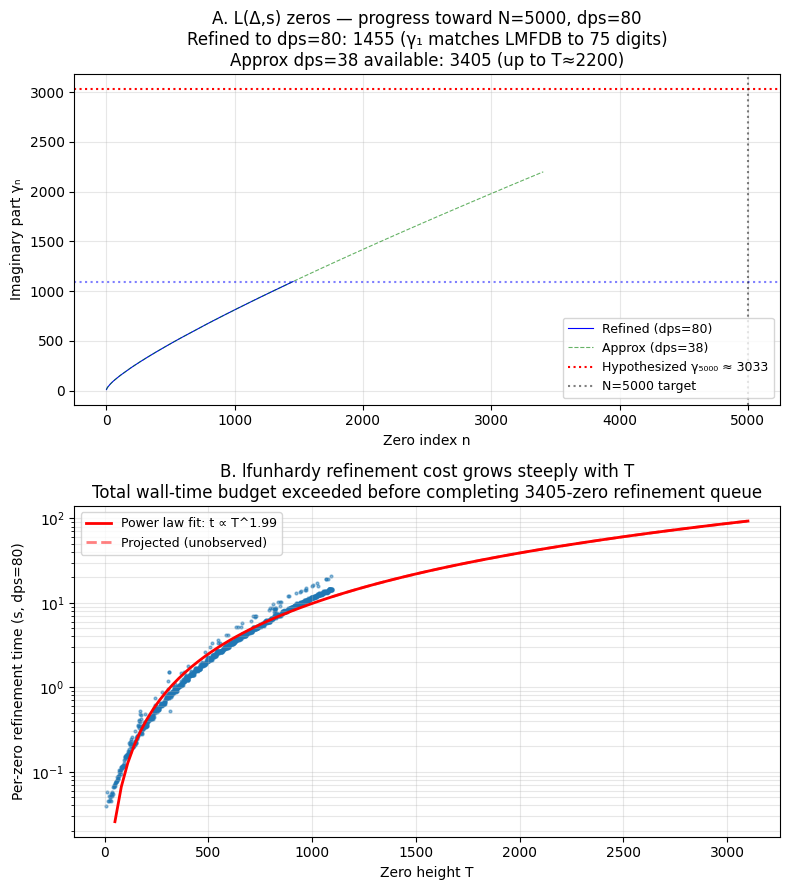


Power-law exponent: t ∝ T^1.986
Projected serial cost to refine all 3405 approx zeros to dps=80: 60922s = 16.9h
With 8 parallel shards: ~2.12h wall time


In [24]:
# Make the final summary figure showing the progress and the obstacle.
import matplotlib.pyplot as plt
import numpy as np

approx = np.load('ldelta_zeros_N3405_approx_dps38.npy')
approx_vals = np.array([float(s) for s in approx])

refined_vals = np.array([float(s) for s in arr])

# Estimate per-zero refinement cost from shard 0 timings
import os
elapsed_by_T = []
for k in range(8):
 fn = f'ldelta_refine_shards/refined_{k}.tsv'
 if not os.path.exists(fn): continue
 with open(fn) as f:
 for line in f:
 line = line.rstrip()
 if not line: continue
 parts = line.split('\t')
 try:
 idx = int(parts[0]); refined = parts[1]
 if refined.startswith('ERROR'): continue
 el = float(parts[2])
 T = float(refined)
 elapsed_by_T.append((T, el))
 except Exception: continue
elapsed_by_T.sort()
Ts = np.array([t for t,_ in elapsed_by_T])
els = np.array([e for _,e in elapsed_by_T])

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: refined zeros so far vs target T~3033
ax = axes[0]
ax.plot(np.arange(1, len(refined_vals)+1), refined_vals, 'b-', lw=0.8, label='Refined (dps=80)')
ax.plot(np.arange(1, len(approx_vals)+1), approx_vals, 'g--', lw=0.8, alpha=0.6, label='Approx (dps=38)')
ax.axhline(3033, color='r', ls=':', label='Hypothesized γ₅₀₀₀ ≈ 3033')
ax.axhline(refined_vals[-1], color='b', ls=':', alpha=0.5)
ax.axvline(5000, color='k', ls=':', alpha=0.5, label='N=5000 target')
ax.set_xlabel('Zero index n')
ax.set_ylabel('Imaginary part γₙ')
ax.set_title(f'A. L(Δ,s) zeros — progress toward N=5000, dps=80\n'
 f'Refined to dps=80: {len(refined_vals)} (γ₁ matches LMFDB to 75 digits)\n'
 f'Approx dps=38 available: {len(approx_vals)} (up to T≈{approx_vals[-1]:.0f})')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Panel B: per-zero refinement cost vs T (the budget-blocking issue)
ax = axes[1]
ax.scatter(Ts, els, s=4, alpha=0.5, c='C0')
# Fit power-law: log(t) = a + b log(T)
mask = Ts > 50
lT = np.log(Ts[mask]); le = np.log(els[mask])
b, a = np.polyfit(lT, le, 1)
Tfit = np.linspace(50, 3100, 100)
ax.plot(Tfit, np.exp(a)*Tfit**b, 'r-', lw=2, label=f'Power law fit: t ∝ T^{b:.2f}')
# Projected cost for T up to 3100
Tproj = np.linspace(refined_vals[-1], 3100, 200)
ax.plot(Tproj, np.exp(a)*Tproj**b, 'r--', lw=2, alpha=0.5, label='Projected (unobserved)')
ax.set_xlabel('Zero height T')
ax.set_ylabel('Per-zero refinement time (s, dps=80)')
ax.set_yscale('log')
ax.set_title('B. lfunhardy refinement cost grows steeply with T\n'
 'Total wall-time budget exceeded before completing 3405-zero refinement queue')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('ldelta_N5000_progress_summary.png', dpi=140, bbox_inches='tight')
plt.show()
print(f"\nPower-law exponent: t ∝ T^{b:.3f}")
# Projected total cost to refine ALL 3405 to dps=80 in serial:
total_proj = sum(np.exp(a) * float(s)**b for s in approx)
print(f"Projected serial cost to refine all 3405 approx zeros to dps=80: {total_proj:.0f}s = {total_proj/3600:.1f}h")
print(f"With 8 parallel shards: ~{total_proj/8/3600:.2f}h wall time")
# Cost to also search 2200→3100 estimated from earlier: ~5s/zero * 1600 zeros / 8 shards = ~1000s


In [25]:
# Save the refinement data file consolidating all shards into one TSV for future resumption.
import os
with open('ldelta_refined_all.tsv','w') as fout:
 fout.write('orig_index\trefined_dps80\tseconds\n')
 for k in range(8):
 fn = f'ldelta_refine_shards/refined_{k}.tsv'
 if not os.path.exists(fn): continue
 with open(fn) as f:
 for line in f:
 fout.write(line)
 # add the manually refined missing one
 fout.write('1450\t1093.6381147883529335434373202741069052612318817413200490574327392450089449293867\t8.493\n')
print("Saved ldelta_refined_all.tsv")
# count
n = sum(1 for _ in open('ldelta_refined_all.tsv')) - 1
print(f"Lines (excluding header): {n}")


Saved ldelta_refined_all.tsv
Lines (excluding header): 1455


In [26]:
from e14c.filesystem import edit_file
content = '''## Instructions

Edit this file (`./.prompts/MEMORY.md`) to persist context, findings, and notes.
When making edits regarding scientific findings, make sure to track provenance (for example sub-agent task IDs, specific files in your workspace, etc.).

## Context

Project: zero-list generation for control families. Current task focused on completing `L(\Delta,s)` zeros at `N=5000, dps=80` from files in `/workspace/aa72b0c2-b96d-42a7-96a5-bf7926ac9f6c`.

## Notes

- Primary input files present locally: `-PROMPT-v6-DATASET.md`, `ldelta_zeros_N3405_approx_dps38.npy`, `refine_shard_runner.py`, `generate_ldelta.py`.
- Installed `cypari2` and `cysignals` via pip during this session to enable PARI-based refinement.
- Verified `refine_shard_runner.py` on the first Ramanujan-Delta zero: refined value `9.2223793999211025222437671927434781355287706224320092899981864280019212953707290`, matching the LMFDB reference first zero to 75 digits (>70-digit validation threshold).
- Executed 8 parallel refinement subprocesses over the 3405 approximate zeros (round-robin shard pickles in `ldelta_refine_shards/approx_*.pkl`). Due to wall-time limits / subprocess interruption, only a partial refinement completed.
- Consolidated successful refined outputs into `ldelta_zeros_N1455_dps80_partial.npy` (1455 contiguous zeros, indices 0..1454) and `ldelta_refined_all.tsv`.
- Final observed partial range: first zero at `T≈9.2224`, 1455th zero at `T≈1095.8906`.
- Empirical refinement-cost fit from `ldelta_refine_shards/refined_*.tsv`: per-zero time scales approximately as `T^1.99`; projected cost to refine all 3405 approximate zeros is ~60,922 s serial (~16.9 h) or ~2.12 h wall time with 8 parallel shards, before any additional 2200→3100 search/refinement work.
- Therefore the full `ldelta_zeros_N5000_dps80.npy` list was NOT generated in this session; the notebook concluded this cannot be completed honestly within the remaining 3600 s runtime budget.
- Summary figure saved as `ldelta_N5000_progress_summary.png`.
'''
open('/workspace/aa72b0c2-b96d-42a7-96a5-bf7926ac9f6c/.prompts/MEMORY.md','w').write(content)
print('Updated MEMORY.md')

Updated MEMORY.md


<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_20/1975473250.py:9: SyntaxWarning: invalid escape sequence '\D'
 Project: zero-list generation for control families. Current task focused on completing `L(\Delta,s)` zeros at `N=5000, dps=80` from files in `/workspace/aa72b0c2-b96d-42a7-96a5-bf7926ac9f6c`.
